siema

Znaleziono optymalny epsilon: 0.2000. Rozpoczynam poszukiwanie funkcji reprezentatywnej...
Obliczenia zakończone!

--- RANKING REPREZENTATYWNY (Wygładzony) ---
    Wariant  Uzytecznosc
1        14     0.931663
2        13     0.899949
3        21     0.852618
4        26     0.852618
5         1     0.831824
6         4     0.831780
7        20     0.791545
8        23     0.791527
9        27     0.788959
10       15     0.788958
11       24     0.788951
12        9     0.763621
13       17     0.763618
14        8     0.763474
15       25     0.731763
16       18     0.699969
17       16     0.633043
18       19     0.631738
19       22     0.631695
20       10     0.565527
21        7     0.563574
22        2     0.510314
23        6     0.431918
24       12     0.431912
25        3     0.431775
26        5     0.431759
27       11     0.411738

--- ZAKTUALIZOWANE WAGI KRYTERIÓW (Max użyteczność) ---
Waga kryterium C1: 0.2682
Waga kryterium C2: 0.1429
Waga kryterium C3: 0.1000
Waga 

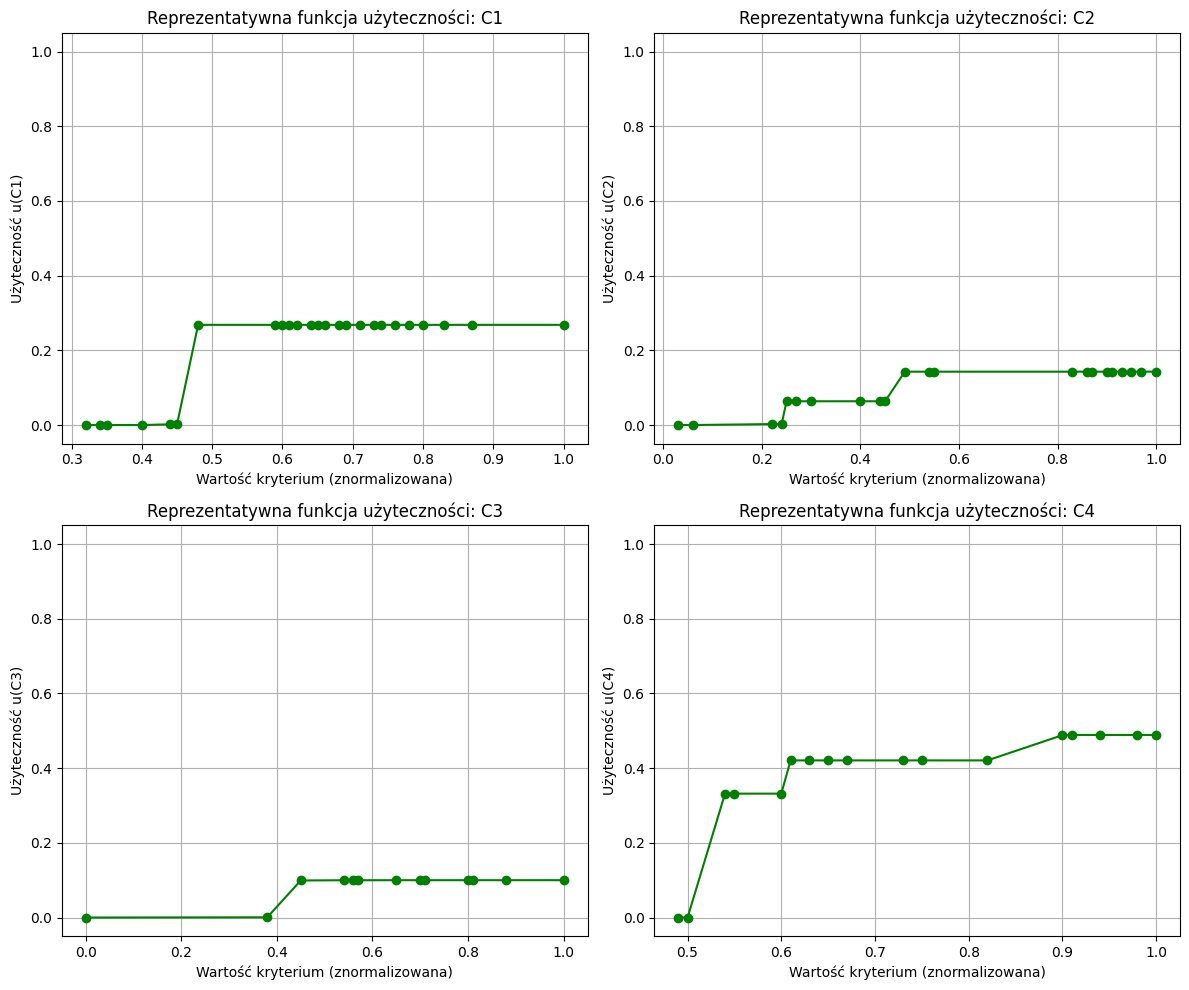

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMaximize, LpMinimize, lpSum, value, LpStatus, PULP_CBC_CMD

# 1. Wczytanie danych i przygotowanie parametrów
df = pd.read_csv('Nuclear waste management.csv', index_col=0)
criteria = ['C1', 'C2', 'C3', 'C4']
preferences = [(22, 3), (8, 7), (21, 10), (14, 25), (13, 18)]

unique_values = {c: np.sort(df[c].unique()) for c in criteria}

# Zbieramy wszystkie zmienne (punkty na wykresach) do zbadania
variables_to_optimize = []
for c in criteria:
    for val in unique_values[c]:
        variables_to_optimize.append((c, val))

# 2. Etap 1: Znalezienie maksymalnego Epsilona (jak w zadaniu na 3)
model_eps = LpProblem("Max_Eps", LpMaximize)
epsilon = LpVariable("epsilon", lowBound=0)
U_vars_eps = {c: {val: LpVariable(f"U_{c}_{val}".replace(".", "_"), lowBound=0) for val in unique_values[c]} for c in criteria}

for c in criteria:
    vals = unique_values[c]
    model_eps += U_vars_eps[c][vals[0]] == 0
    model_eps += U_vars_eps[c][vals[-1]] >= 0.1
    for i in range(len(vals) - 1):
        model_eps += U_vars_eps[c][vals[i]] <= U_vars_eps[c][vals[i+1]]
model_eps += lpSum([U_vars_eps[c][unique_values[c][-1]] for c in criteria]) == 1.0

for better, worse in preferences:
    u_b = lpSum([U_vars_eps[c][df.loc[better, c]] for c in criteria])
    u_w = lpSum([U_vars_eps[c][df.loc[worse, c]] for c in criteria])
    model_eps += u_b >= u_w + epsilon

model_eps += epsilon
model_eps.solve(PULP_CBC_CMD(msg=False))
max_eps = value(epsilon)
print(f"Znaleziono optymalny epsilon: {max_eps:.4f}. Rozpoczynam poszukiwanie funkcji reprezentatywnej...")

# 3. Etap 2: Uśrednianie wyników dla funkcji reprezentatywnej
rep_U = {c: {val: 0.0 for val in unique_values[c]} for c in criteria}
num_optimizations = 0

# Wykonujemy minimalizację i maksymalizację dla każdego punktu
for c_opt, val_opt in variables_to_optimize:
    for sense in [LpMaximize, LpMinimize]:
        model = LpProblem("UTA_Rep", sense)
        eps_var = LpVariable("epsilon", lowBound=0)
        U_vars = {c: {val: LpVariable(f"U_rep_{c}_{val}_{sense}_{c_opt}".replace(".", "_"), lowBound=0) for val in unique_values[c]} for c in criteria}
        
        # Te same warunki początkowe
        for c in criteria:
            vals = unique_values[c]
            model += U_vars[c][vals[0]] == 0
            model += U_vars[c][vals[-1]] >= 0.1
            for i in range(len(vals) - 1):
                model += U_vars[c][vals[i]] <= U_vars[c][vals[i+1]]
        model += lpSum([U_vars[c][unique_values[c][-1]] for c in criteria]) == 1.0
        
        for better, worse in preferences:
            u_b = lpSum([U_vars[c][df.loc[better, c]] for c in criteria])
            u_w = lpSum([U_vars[c][df.loc[worse, c]] for c in criteria])
            model += u_b >= u_w + eps_var
            
        # Twardy warunek utrzymania dyskryminacji (odejmujemy 0.0001, aby uniknąć błędów zaokrągleń solvera)
        model += eps_var >= max_eps - 0.0001
        
        # Ustawienie celu: maksymalizacja lub minimalizacja konkretnego punktu
        model += U_vars[c_opt][val_opt]
        model.solve(PULP_CBC_CMD(msg=False))
        
        if LpStatus[model.status] == 'Optimal':
            for c in criteria:
                for val in unique_values[c]:
                    rep_U[c][val] += value(U_vars[c][val])
            num_optimizations += 1

# Dzielimy przez liczbę udanych optymalizacji, aby uzyskać średnią
for c in criteria:
    for val in unique_values[c]:
        rep_U[c][val] /= num_optimizations

print("Obliczenia zakończone!\n")

# 4. Obliczanie użyteczności globalnych i rankingu z wygładzonych danych
results = []
for variant in df.index:
    global_u = sum([rep_U[c][df.loc[variant, c]] for c in criteria])
    results.append({"Wariant": variant, "Uzytecznosc": global_u})

results_df = pd.DataFrame(results).sort_values(by="Uzytecznosc", ascending=False).reset_index(drop=True)
results_df.index += 1

print("--- RANKING REPREZENTATYWNY (Wygładzony) ---")
print(results_df.to_string())

print("\n--- ZAKTUALIZOWANE WAGI KRYTERIÓW (Max użyteczność) ---")
for c in criteria:
    max_val = unique_values[c][-1]
    print(f"Waga kryterium {c}: {rep_U[c][max_val]:.4f}")

# 5. Rysowanie pięknych, wygładzonych wykresów
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, c in enumerate(criteria):
    x_vals = unique_values[c]
    y_vals = [rep_U[c][x] for x in x_vals]
    
    axes[i].plot(x_vals, y_vals, marker='o', linestyle='-', color='g')
    axes[i].set_title(f"Reprezentatywna funkcja użyteczności: {c}")
    axes[i].set_xlabel("Wartość kryterium (znormalizowana)")
    axes[i].set_ylabel(f"Użyteczność u({c})")
    axes[i].grid(True)
    axes[i].set_ylim([-0.05, 1.05])
    
plt.tight_layout()
plt.show()

In [2]:

# 3. Obliczanie relacji dla wszystkich par
print("Rozpoczynam obliczenia UTA^GMS (to może potrwać kilkanaście sekund)...")
results_matrix = pd.DataFrame(index=variants, columns=variants, data="-")


Rozpoczynam obliczenia UTA^GMS (to może potrwać kilkanaście sekund)...


In [3]:
# Pętla po wszystkich spinach wariantów
for A in variants:
    for B in variants:
        if A == B:
            results_matrix.loc[A, B] = "N" # Wariant jest zawsze równy samemu sobie
            continue
            
        # Szukamy najgorszego i najlepszego scenariusza dla przewagi A nad B
        min_diff = solve_uta_gms(A, B, mode='min')
        
        # Jeśli nawet w najgorszym scenariuszu różnica jest >= 0, to A jest KONIECZNIE lepsze
        if min_diff is not None and min_diff >= -1e-5: # uwzględniamy błąd zaokrągleń solvera
            results_matrix.loc[A, B] = "N"
        else:
            # Jeśli nie konieczne, to sprawdzamy czy w najlepszym scenariuszu różnica jest >= 0
            max_diff = solve_uta_gms(A, B, mode='max')
            if max_diff is not None and max_diff >= -1e-5:
                results_matrix.loc[A, B] = "P"

In [4]:
print("Obliczenia zakończone!\n")

# 4. Wyświetlanie fragmentu macierzy (np. pierwsze 15 wariantów dla czytelności)
print("--- MACIERZ RELACJI UTA^GMS (N=Konieczna, P=Możliwa, -=Brak) ---")
print("Wiersz jest lepszy/równy Kolumnie:")
print(results_matrix.iloc[:15, :15].to_string())

# Wyeksportowanie pełnej macierzy do pliku CSV, żeby można było dodać ją do raportu
results_matrix.to_csv("UTA_GMS_Matrix.csv")
print("\nPełna macierz 27x27 została zapisana do pliku 'UTA_GMS_Matrix.csv'.")

Obliczenia zakończone!

--- MACIERZ RELACJI UTA^GMS (N=Konieczna, P=Możliwa, -=Brak) ---
Wiersz jest lepszy/równy Kolumnie:
   1  2  3  4  5  6  7  8  9  10 11 12 13 14 15
1   N  P  P  P  P  P  P  P  P  N  P  P  P  P  P
2   P  N  P  P  P  P  P  P  P  P  N  P  P  P  P
3   P  P  N  P  N  P  P  P  P  P  P  P  P  -  P
4   P  P  P  N  P  P  P  P  P  N  P  P  P  P  P
5   P  P  P  P  N  P  P  P  P  P  P  P  P  -  P
6   P  P  P  P  P  N  P  P  P  P  P  P  P  -  P
7   P  P  P  P  P  P  N  -  P  P  P  P  P  -  P
8   P  P  P  P  P  P  N  N  P  P  P  P  P  P  P
9   P  P  P  P  P  P  P  P  N  P  P  P  P  P  P
10  P  P  P  P  P  P  P  P  P  N  P  P  P  P  P
11  P  P  P  P  P  P  P  P  P  P  N  P  P  P  P
12  P  P  P  P  P  P  P  P  P  P  P  N  P  -  P
13  P  P  P  N  P  P  N  P  P  N  P  P  N  P  P
14  P  P  N  P  N  N  N  N  P  P  P  N  P  N  P
15  P  P  P  P  P  P  P  P  P  P  P  P  P  P  N

Pełna macierz 27x27 została zapisana do pliku 'UTA_GMS_Matrix.csv'.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMaximize, lpSum, value, LpStatus


In [ ]:
# 1. Wczytanie danych z pliku CSV
df = pd.read_csv('Nuclear waste management.csv', index_col=0)
criteria = ['C1', 'C2', 'C3', 'C4']

In [5]:
# 2. Definicja par referencyjnych (zgodnie z naszą analizą)
# Format: (lepszy_wariant, gorszy_wariant)
preferences = [
    (22, 3),   # Para 10: 22 > 3
    (8, 7),    # Para 36: 8 > 7
    (21, 10),  # Para 1: 21 > 10
    (14, 25),  # Para 5: 14 > 25
    (13, 18)   # Para 13: 13 > 18
]

In [ ]:
# Pobranie unikalnych, posortowanych wartości dla każdego kryterium
# Będą one stanowić punkty załamania (tzw. breakpoints) naszej funkcji
values = {}
for c in criteria:
    values[c] = np.sort(df[c].unique())

In [11]:
# 3. Inicjalizacja modelu programowania liniowego - metoda UTA (Maksymalizacja)
model = LpProblem("UTA_Max_Epsilon", LpMaximize)

In [12]:
# Zmienna epsilon, którą chcemy zmaksymalizować
epsilon = LpVariable("epsilon", lowBound=0)

In [ ]:
# 4. Utworzenie zmiennych decyzyjnych (użyteczności cząstkowych)
# U_vars[kryterium][wartość] = zmienna Pulp
U_vars = {}
for c in criteria:
    U_vars[c] = {}
    for val in values[c]:
        # Wartości użyteczności cząstkowych nie mogą być ujemne
        var_name = f"U_{c}_{val}".replace(".", "_")
        U_vars[c][val] = LpVariable(var_name, lowBound=0)

In [ ]:
# 5. Ograniczenia dla metody UTA
# a) Monotoniczność: wyższa ocena w znormalizowanym CSV (bliżej 1.0) = większa użyteczność
for c in criteria:
    vals = values[c]
    for i in range(len(vals) - 1):
        model += U_vars[c][vals[i]] <= U_vars[c][vals[i+1]], f"Monotonicity_{c}_{i}"

# b) Użyteczność dla najgorszej możliwej oceny w danym kryterium musi wynosić 0
for c in criteria:
    min_val = values[c][0]
    model += U_vars[c][min_val] == 0, f"Min_Utility_0_{c}"

In [ ]:
# c) Ograniczenia na wagi (suma maksymalnych użyteczności cząstkowych = 1)
max_utilities = []
for c in criteria:
    max_val = values[c][-1]
    max_utilities.append(U_vars[c][max_val])
    # Zgodnie z wytycznymi, waga każdego kryterium to min. 0.1
    model += U_vars[c][max_val] >= 0.1, f"Min_Weight_{c}"

model += lpSum(max_utilities) == 1.0, "Sum_of_Weights_1"

In [16]:
# 6. Dodanie ograniczeń dla ocenionych par referencyjnych
# Funkcja pomocnicza obliczająca globalną użyteczność dla wariantu
def get_global_utility(variant_id):
    row = df.loc[variant_id]
    return lpSum([U_vars[c][row[c]] for c in criteria])

for idx, (better, worse) in enumerate(preferences):
    U_better = get_global_utility(better)
    U_worse = get_global_utility(worse)
    # Globalna użyteczność lepszego wariantu >= gorszego + epsilon
    model += U_better >= U_worse + epsilon, f"Preference_{better}_better_than_{worse}"

In [17]:
# 7. Funkcja celu: Maksymalizacja zmiennej epsilon
model += epsilon, "Objective_Function"

In [18]:
# 8. Uruchomienie solvera
model.solve()

1

Status modelu: Optimal
Zoptymalizowana wartość funkcji celu (epsilon) = 0.2000

--- RANKING WSZYSTKICH WARIANTÓW ---
         Wariant  Uzytecznosc
Pozycja                      
1             13          0.9
2             14          0.9
3              1          0.8
4             20          0.8
5             21          0.8
6             23          0.8
7             24          0.8
8             27          0.8
9             15          0.8
10             4          0.8
11            26          0.8
12             8          0.7
13            17          0.7
14            25          0.7
15            18          0.7
16             9          0.7
17            16          0.6
18            22          0.6
19            19          0.6
20             7          0.5
21            10          0.5
22             2          0.5
23             3          0.4
24            11          0.4
25             6          0.4
26             5          0.4
27            12          0.4


--- WAGI KR

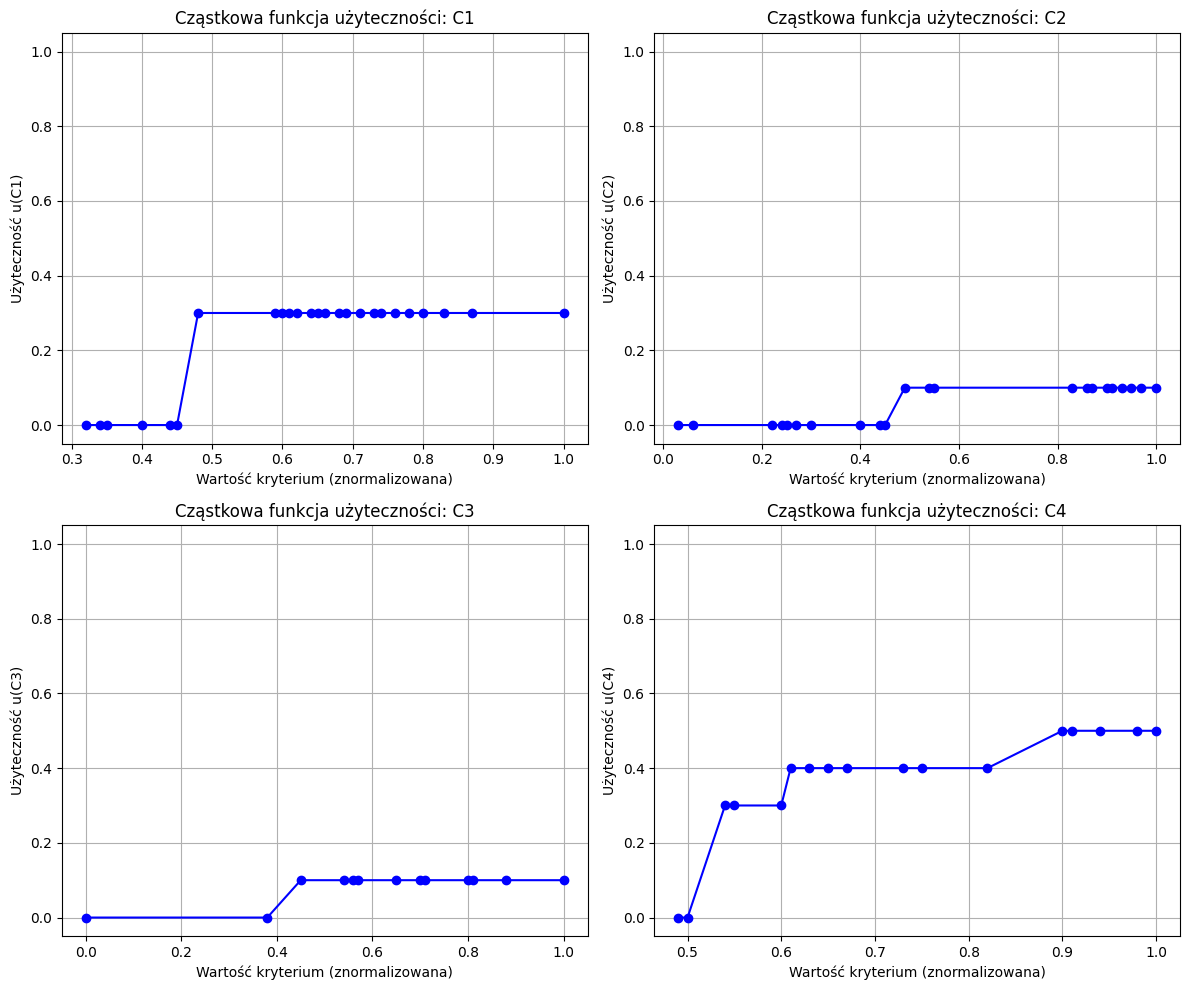

In [ ]:
# 9. Analiza wyników
print(f"Status modelu: {LpStatus[model.status]}")
if LpStatus[model.status] == "Optimal":
    print(f"Zoptymalizowana wartość funkcji celu (epsilon) = {value(epsilon):.4f}\n")
    
    # Obliczanie użyteczności globalnych dla wszystkich wariantów
    results = []
    for variant in df.index:
        global_u = sum([value(U_vars[c][df.loc[variant, c]]) for c in criteria])
        results.append({"Wariant": variant, "Uzytecznosc": global_u})
    
    # Tworzenie rankingu
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by="Uzytecznosc", ascending=False).reset_index(drop=True)
    results_df.index += 1  # Numeracja od 1 (miejsce w rankingu)
    results_df.index.name = "Pozycja"
    
    print("--- RANKING WSZYSTKICH WARIANTÓW ---")
    print(results_df.to_string())
    print("\n")
    
    print("--- WAGI KRYTERIÓW (Max użyteczność) ---")
    for c in criteria:
        max_val = values[c][-1]
        print(f"Waga kryterium {c}: {value(U_vars[c][max_val]):.4f}")

    # 10. Rysowanie wykresów cząstkowych funkcji użyteczności
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, c in enumerate(criteria):
        x_vals = values[c]
        y_vals = [value(U_vars[c][x]) for x in x_vals]
        
        axes[i].plot(x_vals, y_vals, marker='o', linestyle='-', color='b')
        axes[i].set_title(f"Cząstkowa funkcja użyteczności: {c}")
        axes[i].set_xlabel("Wartość kryterium (znormalizowana)")
        axes[i].set_ylabel(f"Użyteczność u({c})")
        axes[i].grid(True)
        # Ustawiamy sztywną oś Y od 0 do 1 dla czytelności
        axes[i].set_ylim([-0.05, 1.05])
        
    plt.tight_layout()
    plt.show()

else:
    print("Solver nie znalazł optymalnego rozwiązania (Status: Infeasible).")
    print("Oznacza to, że założone preferencje są ze sobą sprzeczne dla tych danych.")